# Word Embedding and NLP Representation Learning

This notebook demonstrates the cleaned portfolio workflow built from the supplied
TF-IDF + SVD project. The primary saved model is a PyTorch neural skip-gram embedding
model, while the supplied LSA approach is retained as a baseline.

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_preprocessing import load_included_corpus, corpus_summary, load_topic_lexicon
from src.embedding_pipeline import load_embedding_bundle
from src.embedding_analysis import (
    build_sentence_embedding_table,
    pca_projection,
    semantic_search,
)
from src.baseline_representations import build_lsa_term_embeddings

pd.set_option("display.max_colwidth", 100)
print("Project root:", PROJECT_ROOT)

Project root: /mnt/data/simple-rnn-projects-word-embedding-update/06-word-embedding


## 1. Load and inspect the included corpus

In [2]:
corpus = load_included_corpus()
print("Corpus shape:", corpus.shape)
corpus[["sentence_id", "topic", "text", "source_type"]].head()

Corpus shape: (1020, 5)


,sentence_id,topic,text,source_type
0,s0000,artificial_intelligence,algorithm and neural are closely related concepts in artificial intelligence.,synthetic_privacy_safe
1,s0001,artificial_intelligence,Professionals use token with representation to improve training.,synthetic_privacy_safe
2,s0002,artificial_intelligence,A strong algorithm process supports better classification and model.,synthetic_privacy_safe
3,s0003,artificial_intelligence,The sequence system analyzes machine before producing network.,synthetic_privacy_safe
4,s0004,artificial_intelligence,neural depends on accurate model and reliable language.,synthetic_privacy_safe


In [3]:
corpus_summary(corpus)

,topic,source_type,sentences,mean_tokens
0,artificial_intelligence,synthetic_privacy_safe,220,9.263636
1,energy,synthetic_privacy_safe,200,9.050000
2,finance,synthetic_privacy_safe,200,8.950000
3,healthcare,synthetic_privacy_safe,200,8.950000
4,quality_manufacturing,synthetic_privacy_safe,200,9.390000


The deployed project uses a synthetic, privacy-safe corpus so that inference does not
depend on an external network download. The optional 20 Newsgroups loader is available
for local experimentation but is not required here.

## 2. Load saved neural embedding artifacts

In [4]:
bundle = load_embedding_bundle()
metadata = bundle.metadata
{
    "vocabulary_size": metadata["vocabulary_size"],
    "embedding_dimension": metadata["embedding_dimension"],
    "window_size": metadata["window_size"],
    "matrix_shape": bundle.embedding_matrix.shape,
}

{'vocabulary_size': 171,
 'embedding_dimension': 32,
 'window_size': 2,
 'matrix_shape': (171, 32)}

## 3. Inspect learned nearest-word relationships

In [5]:
for word in ["model", "market", "doctor", "electricity", "quality"]:
    print(f"\nNearest words for: {word}")
    display(bundle.nearest(word, top_k=5)[["word", "similarity"]])


Nearest words for: model


,word,similarity
0,inference,0.707778
1,learning,0.705872
2,classification,0.691568
3,feature,0.622204
4,prediction,0.519282



Nearest words for: market


,word,similarity
0,investor,0.530341
1,volatility,0.527340
2,bond,0.519250
3,security,0.463157
4,risk,0.445899



Nearest words for: doctor


,word,similarity
0,recovery,0.592326
1,disease,0.527377
2,clinic,0.523177
3,storage,0.491075
4,prescription,0.489394



Nearest words for: electricity


,word,similarity
0,renewable,0.585495
1,energy,0.581884
2,consumption,0.448196
3,carbon,0.439760
4,grid,0.435911



Nearest words for: quality


,word,similarity
0,defect,0.521978
1,failure,0.513377
2,inspection,0.495047
3,manufacturing,0.474964
4,improvement,0.420751


## 4. Convert a sentence to token and embedding representations

In [6]:
sentence = "quality inspection finds a manufacturing defect"
result = bundle.encode_sentence(sentence)
{
    "cleaned_text": result["cleaned_text"],
    "tokens": result["tokens"],
    "indices": result["indices"],
    "known_tokens": result["known_tokens"],
    "oov_tokens": result["oov_tokens"],
    "token_embedding_matrix_shape": result["token_embedding_matrix"].shape,
    "sentence_vector_shape": result["sentence_vector"].shape,
}

{'cleaned_text': 'quality inspection finds a manufacturing defect',
 'tokens': ['quality', 'inspection', 'finds', 'a', 'manufacturing', 'defect'],
 'indices': [15, 124, 1, 8, 16, 61],
 'known_tokens': ['quality', 'inspection', 'a', 'manufacturing', 'defect'],
 'oov_tokens': ['finds'],
 'token_embedding_matrix_shape': (5, 32),
 'sentence_vector_shape': (32,)}

In [7]:
pd.DataFrame(
    result["token_embedding_matrix"][:, :8],
    index=result["known_tokens"],
    columns=[f"dim_{index:02d}" for index in range(8)],
)

,dim_00,dim_01,dim_02,dim_03,dim_04,dim_05,dim_06,dim_07
quality,1.073168,0.722457,-1.651217,-0.352025,0.276115,-0.339944,-0.906667,-1.540267
inspection,-0.729822,0.239709,-0.301975,-0.356580,1.001059,-0.055068,-0.769962,-0.001642
a,-0.562557,1.027961,-2.150294,-0.126449,-3.000632,-1.142242,-0.318462,1.608623
manufacturing,-2.172150,0.671357,0.339073,-0.244864,1.678896,0.578080,-0.928268,-1.171375
defect,-1.118730,0.237976,-0.413574,-1.817817,0.754577,0.767924,-0.500571,-0.012638


## 5. Semantic sentence search

In [8]:
searchable_corpus, corpus_vectors = build_sentence_embedding_table(
    corpus,
    bundle.word_to_index,
    bundle.embedding_matrix,
)
semantic_search(
    "root cause quality failure",
    searchable_corpus,
    corpus_vectors,
    bundle.word_to_index,
    bundle.embedding_matrix,
    top_k=5,
)[["topic", "similarity", "text"]]

,topic,similarity,text
0,quality_manufacturing,0.733833,Quality analytics connects defect patterns with root cause and process improvement.
1,quality_manufacturing,0.733833,Quality analytics connects defect patterns with root cause and process improvement.
2,quality_manufacturing,0.733833,Quality analytics connects defect patterns with root cause and process improvement.
3,quality_manufacturing,0.733833,Quality analytics connects defect patterns with root cause and process improvement.
4,quality_manufacturing,0.733833,Quality analytics connects defect patterns with root cause and process improvement.


## 6. Two-dimensional PCA visualization

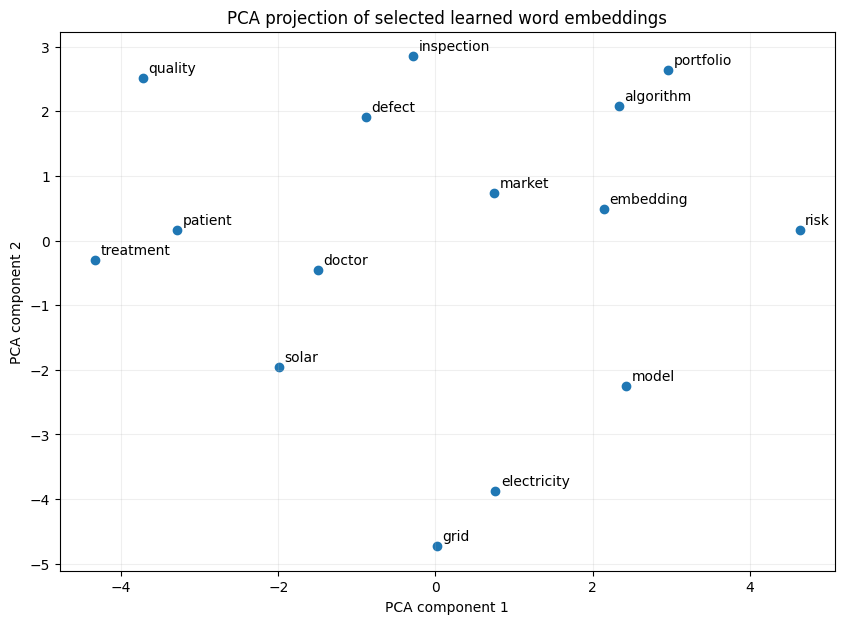

In [9]:
selected_words = [
    "model", "embedding", "algorithm", "market", "risk", "portfolio",
    "doctor", "patient", "treatment", "electricity", "grid", "solar",
    "quality", "defect", "inspection",
]
projection = pca_projection(
    selected_words,
    bundle.word_to_index,
    bundle.embedding_matrix,
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(projection["x"], projection["y"])
for _, row in projection.iterrows():
    ax.annotate(row["word"], (row["x"], row["y"]), xytext=(4, 4), textcoords="offset points")
ax.set_title("PCA projection of selected learned word embeddings")
ax.set_xlabel("PCA component 1")
ax.set_ylabel("PCA component 2")
ax.grid(alpha=0.2)
plt.show()

## 7. Compare with the supplied TF-IDF + SVD baseline

In [10]:
_, _, lsa_terms, lsa_embeddings, _ = build_lsa_term_embeddings(
    corpus["text"].tolist(),
    max_features=500,
    embedding_dimension=32,
)
print("LSA vocabulary size:", len(lsa_terms))
print("LSA term-embedding shape:", lsa_embeddings.shape)

comparison = pd.read_csv(PROJECT_ROOT / "outputs" / "representation_comparison.csv")
comparison

LSA vocabulary size: 168
LSA term-embedding shape: (168, 32)


,representation,vector_type,captures_similarity,preserves_word_order,portfolio_role,domain_purity_at_5
0,One-hot encoding,Sparse,No,No,Conceptual baseline,NaN
1,Bag-of-Words,Sparse,Limited,No,Frequency baseline,NaN
2,TF-IDF,Sparse,Document-level only,No,Weighted baseline,NaN
3,TF-IDF + Truncated SVD,Dense,Latent co-occurrence,No,Original-project LSA baseline,0.806061
4,Neural skip-gram embedding,Dense,Learned local context,Through context windows,Primary model,0.943434


## 8. Saved evaluation results

In [11]:
metrics = json.loads(
    (PROJECT_ROOT / "outputs" / "model_metrics.json").read_text(encoding="utf-8")
)
pd.DataFrame(
    [{"metric": key, "value": value} for key, value in metrics.items()]
)

,metric,value
0,corpus_sentences,1020.000000
1,corpus_tokens,9306.000000
2,domain_purity_at_5,0.943434
3,embedding_dimension,32.000000
4,epochs_completed,59.000000
5,lsa_baseline_domain_purity_at_5,0.806061
6,training_pairs,26438.000000
7,validation_loss,3.306959
8,validation_pairs,4666.000000
9,validation_perplexity,27.301971


## Conclusion

The supplied project was a useful latent-semantic-analysis prototype. The cleaned
portfolio version adds a neural embedding layer, saved inference artifacts, held-out
context evaluation, nearest-neighbor analysis, sentence vectors, semantic search,
tests, CI, and a deployment-ready Streamlit application.

The model is intentionally presented as an educational representation-learning system,
not as a broad production language model.